# `CPPStructurePlot.plot_linked`

The deployed cleavage app's signature interaction: the `CPPPlot.feature_map` and the 3D structure are **linked** — **hover a feature-map column and the corresponding residue lights up in the structure**. `plot_linked` returns a `LinkedView` that renders inline and exports a self-contained, shareable `.html` via `write_html` — for exploring a site and as a publication-figure source.

This is a `pro` feature (needs `biopython` + `py3Dmol`). It is interactive — open the rendered view (or the exported HTML) in a browser and move the mouse across the feature-map columns.

In [1]:
import pandas as pd
import aaanalysis as aa
import aaanalysis.utils as ut

aa.options["verbose"] = False

## A `df_feat` and a real structure

As in the other examples we use the human lysozyme C AlphaFold model (`uniprot='P61626'`) and a `df_feat` with a signed `feat_impact` (from `CPP.run` + `ShapModel` in practice).

In [2]:
df_cat = aa.load_scales(name='scales_cat').head(5).reset_index(drop=True)
splits = ['Segment(1,2)', 'Segment(2,2)', 'Segment(1,1)', 'Pattern(C,1)', 'Segment(1,4)']
parts = ['TMD', 'TMD', 'JMD_N', 'TMD', 'JMD_C']
df_feat = pd.DataFrame({
    ut.COL_FEATURE: [f"{parts[i]}-{splits[i]}-{r[ut.COL_SCALE_ID]}" for i, r in df_cat.iterrows()],
    'category': df_cat[ut.COL_CAT], 'subcategory': df_cat[ut.COL_SUBCAT],
    'scale_name': df_cat[ut.COL_SCALE_NAME],
    'abs_auc': [0.2, 0.15, 0.3, 0.1, 0.25], 'abs_mean_dif': [0.3, 0.2, 0.5, 0.4, 0.35],
    'mean_dif': [0.3, -0.2, 0.5, -0.4, 0.25], 'std_test': 0.1, 'std_ref': 0.1,
    'feat_impact': [0.8, -0.5, 1.2, -0.3, 0.6]})
aa.display_df(df_feat, n_rows=10, show_shape=True)

DataFrame shape: (5, 10)


,feature,category,subcategory,scale_name,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,feat_impact
1,"TMD-Segment(1,2)-LINS030110",ASA/Volume,Accessible surface area (ASA),ASA (folded coil/turn),0.200000,0.300000,0.300000,0.100000,0.100000,0.800000
2,"TMD-Segment(2,2)-LINS030113",ASA/Volume,Accessible surface area (ASA),ASA (folded coil/turn),0.150000,0.200000,-0.200000,0.100000,0.100000,-0.500000
3,"JMD_N-Segment(1,1)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.300000,0.500000,0.500000,0.100000,0.100000,1.200000
4,"TMD-Pattern(C,1)-JANJ780103",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.100000,0.400000,-0.400000,0.100000,0.100000,-0.300000
5,"JMD_C-Segment(1,4)-LINS030104",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.250000,0.350000,0.250000,0.100000,0.100000,0.600000


## The linked view

`focus='zoom'` frames the feature window; `mode` (`impact`/`plddt`) and `size_by_impact` style the structure as in `map_structure`. Hover a column of the feature map → that residue is highlighted (magenta) in the cartoon.


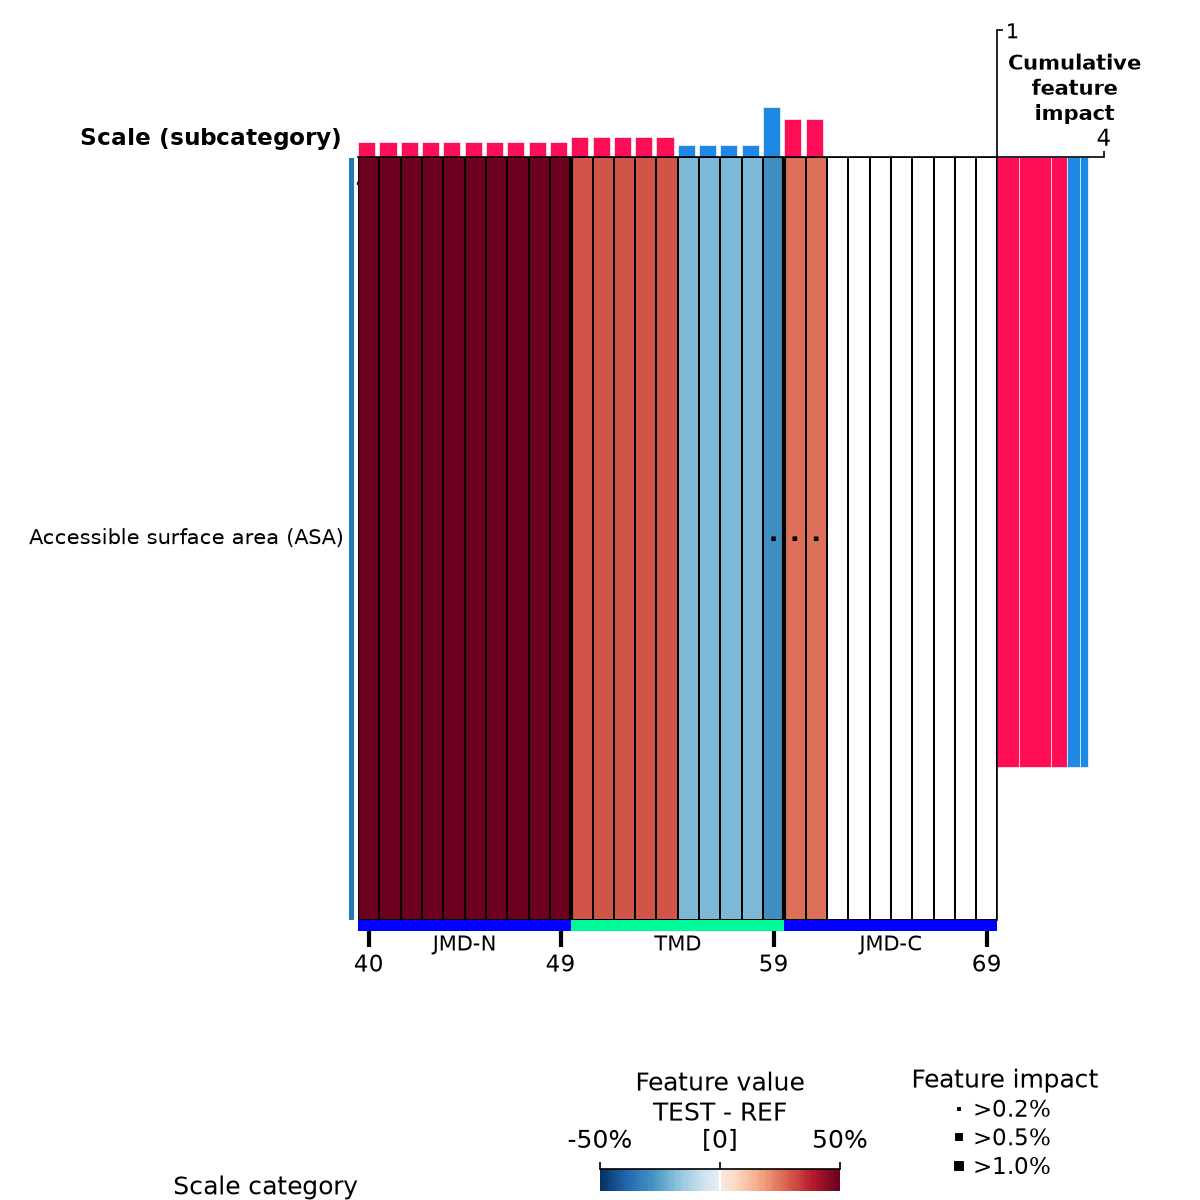

In [3]:
csp = aa.CPPStructurePlot(jmd_n_len=10, jmd_c_len=10, verbose=False)
view = csp.plot_linked(df_feat=df_feat, uniprot='P61626', col_imp='feat_impact',
                       tmd_len=10, start=40, mode='impact', focus='zoom')
view

Export the linked feature-map + structure as one self-contained page (shareable, and a source for a paper figure):

In [4]:
import tempfile, os
out = os.path.join(tempfile.mkdtemp(), 'linked.html')
view.write_html(out)
print('wrote', os.path.basename(out), '(', os.path.getsize(out), 'bytes )')

wrote linked.html ( 173704 bytes )


For a static side-by-side figure use `CPPStructurePlot.plot_combined`; for the 3D structure alone, `CPPStructurePlot.map_structure`; for a live notebook explorer, `CPPStructurePlot.interactive`.